<a href="https://colab.research.google.com/github/PearlJuice1/Innova2022/blob/main/DiD_innova2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import statsmodels.formula.api as smf

In [9]:
# 1. Cargar y preparar los datos

# Cargar datos desde Excel
df = pd.read_excel("DiD_innova2022.xlsx")


In [10]:
# 2. Transformar a formato largo (panel)
# Crear estructura de panel para años 2021 y 2023
df_2021 = df[["empresa", "tratamiento", "Ingresos_2021", "empleados_2021", "otrosGastos _id_2021"]].copy()
df_2021["año"] = 2021
df_2021.rename(columns={
    "Ingresos_2021": "ingresos",
    "empleados_2021": "empleados",
    "otrosGastos _id_2021": "gasto_id"
}, inplace=True)

df_2023 = df[["empresa", "tratamiento", "Ingresos_2023", "empleados_2023", "otrosGastos _id_2023"]].copy()
df_2023["año"] = 2023
df_2023.rename(columns={
    "Ingresos_2023": "ingresos",
    "empleados_2023": "empleados",
    "otrosGastos _id_2023": "gasto_id"
}, inplace=True)

# Combinar ambos años
panel = pd.concat([df_2021, df_2023]).sort_values(by=["empresa", "año"])

In [11]:
# 3. Crear variables necesarias
# Variable post-tratamiento (1 para 2023)
panel["post"] = panel["año"].apply(lambda x: 1 if x == 2023 else 0)

# Variable de interacción tratamiento*post
panel["tratamiento_post"] = panel["tratamiento"] * panel["post"]

# Calcular variables de resultado
panel["productividad"] = panel["ingresos"] / panel["empleados"]
panel["creacion_empleo"] = panel.groupby("empresa")["empleados"].diff()  # Diferencia anual
panel["intensidad_id"] = panel["gasto_id"] / panel["ingresos"]

In [12]:
# 4. Modelo DiD para cada variable de resultado

def run_did_model(df, outcome_var):
    """Función para ejecutar modelo DiD"""
    model = smf.ols(f'{outcome_var} ~ tratamiento + post + tratamiento_post', data=df).fit()
    return model

# Análisis para productividad
modelo_productividad = run_did_model(panel, "productividad")

# Análisis para creación de empleo (solo año 2023)
modelo_empleo = run_did_model(panel[panel["año"] == 2023], "creacion_empleo")

# Análisis para intensidad en I+D
modelo_id = run_did_model(panel, "intensidad_id")

In [13]:
# 5. Resultados
print("="*50)
print("EFECTO EN PRODUCTIVIDAD")
print(modelo_productividad.summary())

print("\n" + "="*50)
print("EFECTO EN CREACIÓN DE EMPLEO")
print(modelo_empleo.summary())

print("\n" + "="*50)
print("EFECTO EN INTENSIDAD DE I+D")
print(modelo_id.summary())

EFECTO EN PRODUCTIVIDAD
                            OLS Regression Results                            
Dep. Variable:          productividad   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                 -0.034
Method:                 Least Squares   F-statistic:                    0.7700
Date:                Wed, 30 Apr 2025   Prob (F-statistic):              0.526
Time:                        17:26:41   Log-Likelihood:                -297.25
No. Observations:                  22   AIC:                             602.5
Df Residuals:                      18   BIC:                             606.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept       

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


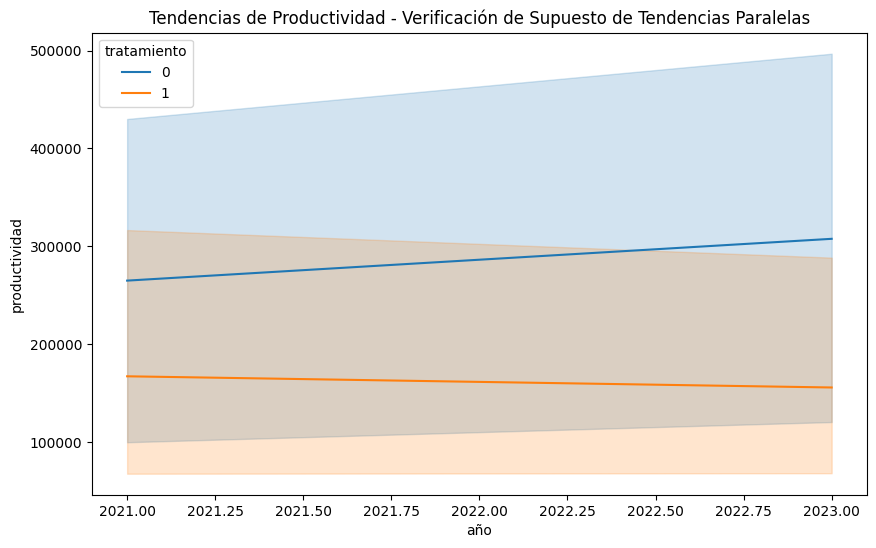

In [14]:
# 6. Visualización de tendencias

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=panel,
    x="año",
    y="productividad",
    hue="tratamiento",
    estimator="mean",
    errorbar=("ci", 95)
)
plt.title("Tendencias de Productividad - Verificación de Supuesto de Tendencias Paralelas")
plt.show()